# Calibrate-Orbitrap-SO4-M0

A notebook to calibrate internal ESI-Orbitrap MS isotopologue delta values of samples, using the measured and true values of isotope standards analysed in a sequence.

Accepts a single M0 sequence.

Uses a Monte-Carlo approach (peturbation of input data by their uncertainties with many repeat calculations) to estimate mean and error of each sample's true $\delta$- and $\Delta$-values. 

The Monte-Carlo scheme outputs calibration-associated ±$1\sigma$ errors. These are combined with measurement SEM to give total uncertainties on calibrated values.

Calibrated data are reported in an excel file.

### Inputs:
- results_'YYYY-MM-DD'.xlsx file(s) containing internal isotopologue measurements of a sequence of samples and standards, eiher a single M0 or an M0 and a noM0 sequence for the same samples. Files must be in a subfolder named 'M0'.
- references_sulphate.xlsx file, with referenced isotope values of the standards measured in the sequence.

### Output:
- 'current-dir'-calibrated-'YYYY-MM-DD'.xlsx, containing sheets for uncalibrated small $\delta$, calibrated small $\delta$, calibration metadata, and pooled uncertainties

In [1]:
import os
import numpy as np
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from datetime import datetime
current_datetime = datetime.now()
current_date_string = current_datetime.strftime("%Y-%m-%d")

# default colours
defcols = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
   

### Find and import Orbitrap data, merge files, drop outlying rows
For automatic identification of files, they must be in appropriate 'M0' or 'noM0' subfolders, and be named 'results.....xlsx'

In [2]:
# FIND data files, decide if M0 or M0+noM0 data present by folder names
paths=[]
n_M0=0; n_noM0=0
# detect folders on path
folders = [folder for folder in os.listdir() if folder.startswith(('m0','nom0','M0','noM0'))]
for folder in folders:
    # select files within folder
    files = [file for file in sorted(os.listdir(folder)) if file.startswith('results') and file.endswith('.xlsx')]
    if len(files)==1:
        file = files[0]
        print('File',file,'found in folder',folder)
    elif len(files)>1.5:
        file = files[-1]
        print('File',file,'found in folder',folder,'(last file alphabetically selected from multiple files)')
    else:
        print('No file found in',folder)
    paths+=[os.path.join(folder,file)]
    # count instances of M0 or noM0 in folder names
    if folder.startswith(('nom0','noM0')):
        n_noM0+=1
    if folder.startswith(('m0','M0')):
        n_M0+=1
# automatically select data type
if n_noM0>0.5 and n_M0>0.5:
    data_type='M0+noM0'
    print('Data type =',data_type)
elif n_M0>0.5:
    data_type='M0-only'
    print('Data type =',data_type)
else:
    print('error selecting data type')
    
### Or manually input filename
# paths = ['250203_DC-2011-2_HSO4_noM0/results_2025-02-08.xlsx',
#          '250131_DC-2011-2_HSO4_M0/results_2025-02-08.xlsx']
### Or manually input data type
# data_type = 'M0-only'
# data_type = 'M0+noM0'


# IMPORT and MERGE data
data=pd.DataFrame()
data_merged = pd.DataFrame(columns=['sample_name'])

# load data from identified paths into a single dataframe
for path in paths:
    data = pd.concat([data, pd.read_excel(path,sheet_name='Bracketed deltas',index_col='Unnamed: 0')],ignore_index=True)
    print('Data loaded',path)

# join data vertically, adding _basepeak as column suffix for delta columns
for bp in data['basepeak'].unique():
    data_bp = data[data['basepeak']==bp].dropna(axis=1,how='all')
    newcols=[]
    for col in data_bp.columns:
        if col.startswith(('d','err_')):
            col+='_'+bp
            newcols+=[col]
        else:
            newcols+=[col]
    data_bp.columns=newcols
    data_merged = pd.concat([data_merged,data_bp], axis=0, ignore_index=True)
    data_merged.reset_index(inplace=True)

# sort rows alphabetically
data_merged = data_merged.loc[sorted(data_merged.index)]

### OPTIONAL INPUT: DROP any unwanted rows using this code
if False:
    to_drop = [] # by index
    data_merged = data_merged.loc[[row for row in data_merged.index if row not in to_drop]]
    print('Dropped rows:',to_drop)
### OPTIONAL INPUT, DROP any suprious values (replace with NaN)
if False:
    row = []
    col = []
    data_merged.loc[row,col]=np.nan
    print('Removed',row,'-',col)
    
# DISPLAY loaded, merged, cleaned data
disp = pd.concat([data_merged['sample_name'],data_merged[[col for col in data_merged.columns if col.startswith(('d','err_'))]]*1e3],axis=1)

print(disp.head())
print('\n\n\n',disp.tail())

File results_2025-10-21.xlsx found in folder m0 (last file alphabetically selected from multiple files)
Data type = M0-only
Data loaded m0/results_2025-10-21.xlsx
  sample_name  d17O_M0  d18O_M0  d33S_M0  d34S_M0  err_d17O_M0  err_d18O_M0  \
0     Alpha-1    -9.35   -12.68     3.39    10.12         2.30         0.86   
1     Alpha-1    -6.72   -13.51     5.47     8.94         2.30         0.87   
2     Alpha-1    -7.01   -12.86     5.40    10.86         2.32         0.86   
3     Alpha-1    -6.30   -13.70     3.98    10.01         2.30         0.82   
4     Alpha-1    -9.28   -10.40     5.97    10.72         2.32         0.87   

   err_d33S_M0  err_d34S_M0  
0         0.88         0.38  
1         0.84         0.38  
2         0.89         0.40  
3         0.86         0.37  
4         0.90         0.39  



     sample_name  d17O_M0  d18O_M0  d33S_M0  d34S_M0  err_d17O_M0  err_d18O_M0  \
175       UW8-3     0.76     1.21    -3.77    -6.55         2.22         0.87   
176       UW8-3 

### Calculate average values for standards
Each standard was prepared multiple repeat times. This block calculates means and standard error on standard delta values of *all* the injections of each standard

In [18]:
# dictionary for consistent renaming of standards
# if needed, edit to match the names in references and sequence files
stds_dict = {'USGS32':'USGS32','USGS34':'USGS34','USGS35':'USGS35',
             'VS':'VolSol',
             'S1':'SMIF1','SMIF1':'SMIF1','S2':'SMIF2','SMIF2':'SMIF2',
             'Alpha':'Sulf-Alpha','alpha':'Sulf-Alpha','Beta':'Sulf-Beta','beta':'Sulf-Beta','Eps':'Sulf-Epsilon','eps':'Sulf-Epsilon','Epsilon':'Sulf-Epsilon','epsilon':'Sulf-Epsilon',
             'UW4':'SodSul4','U4':'SodSul4','SS4':'SodSul4','UWSS4':'SodSul4','UW8':'SodSul8','U8':'SodSul8','SS8':'SodSul8','UWSS8':'SodSul8'
            }

# identify standard rows
data_stds = data_merged.loc[[row for row in data_merged.index if (data_merged.loc[row,'sample_name'].startswith(tuple(stds_dict.keys())))]]
# remove the -1, -2, -3 suffix from standards
for row in data_stds.index:
    if data_stds.loc[row,'sample_name'].endswith(('-1','-2','-3','-4','-5')):
        data_stds.loc[row,'sample_name']=data_stds.loc[row,'sample_name'][:-2]
                
dcols=[col for col in data_stds.columns if col.startswith('d')]

# 1/sigma^2 weighted mean function
def weighted_mean(val,err):
    val = np.asarray(val.dropna(), dtype=float)
    err = np.asarray(err.dropna(), dtype=float)
    w = 1 / err**2
    mean = np.sum(w * val) / np.sum(w)
    # mean_err = np.sqrt(1/ np.sum(w))
    SEM = np.std(val)/np.sqrt(len(val))

    return mean, SEM

# calculate weigted mean for standards
stds_stats=pd.DataFrame(columns=['mean_'+d for d in dcols]+['err_'+d for d in dcols])
for std, group in data_stds.groupby('sample_name'):
    vals={}
    errs={}
    for d in dcols:
        [mean, err] = weighted_mean(group[d],group['err_'+d])
        vals[d]=mean
        errs[d]=err
                                
    stds_stats.loc[stds_dict[std],['mean_'+d for d in dcols]]=list(vals.values())
    stds_stats.loc[stds_dict[std],['err_'+d for d in dcols]]=list(errs.values())

# display averaged standards
stds_stats*1e3

,mean_d17O_M0,mean_d18O_M0,mean_d33S_M0,mean_d34S_M0,err_d17O_M0,err_d18O_M0,err_d33S_M0,err_d34S_M0
Sulf-Alpha,-6.69,-12.09,5.32,10.18,0.58,0.27,0.17,0.14
Sulf-Epsilon,0.24,-11.75,5.22,10.42,0.38,0.24,0.14,0.10
SMIF1,-1.24,-6.48,13.32,10.34,0.52,0.25,0.21,0.27
SMIF2,1.39,-4.26,20.16,19.91,0.61,0.21,0.23,0.11
SodSul4,-1.86,-1.96,1.24,2.47,0.45,0.31,0.24,0.13
SodSul8,1.27,2.31,-3.28,-6.13,0.58,0.21,0.20,0.13


### Calculate and display pooled raw stdev and sem (pre-calibration)
Calculation: 

#### $\sqrt{\frac{\sum \sigma_\delta^2}{n}}$

For standard error $\sigma_\delta$ on $\delta$-values, for $n$ different samples

In [19]:
# calculation pooled error for sample raw deltas
stdlist = pd.DataFrame(columns=[col for col in group.columns if col.startswith('d')])
nlist = pd.DataFrame(columns=[col for col in group.columns if col.startswith('d')])

mask = ~data_merged["sample_name"].str.startswith(tuple(stds_dict.keys()))
data_merged_spls = data_merged[mask]

for spl, group in data_merged_spls.groupby('sample_name'):
    stds = group[[col for col in group.columns if col.startswith('d')]].std()
    n = group[[col for col in group.columns if col.startswith('d')]].count()

    stdlist.loc[spl,:]=stds
    nlist.loc[spl,:]=n

pooled_stdevs = (np.sum(stdlist**2,axis=0)/len(stdlist.index))**0.5
pooled_sems = (np.sum(stdlist**2/nlist.where(nlist!=0),axis=0)/len(stdlist.index))**0.5
nM0_av = nlist[[col for col in nlist.columns if col.endswith('M0')]].mean()
nnoM0_av = nlist[[col for col in nlist.columns if not col.endswith('M0')]].mean()

err_av = data_merged_spls[[col for col in data_merged_spls.columns if col.startswith('err')]].mean()
err_av.index = [col[4:] for col in err_av.index]

pooled_errs_precal = pd.DataFrame()

pooled_errs_precal['Average single injection inter-scan SEM']=err_av
pooled_errs_precal['Pooled sample stdev']=pooled_stdevs
pooled_errs_precal['Pooled sample SEM']=pooled_sems
pooled_errs_precal['Average replicates per sample M0']=nM0_av
pooled_errs_precal['Average replicates per sample no-M0']=nnoM0_av
print('Average M0 replicates per sample = ',f"{nM0_av.mean():.1f}")
print('Average no-M0 replicates per sample = ',f"{nnoM0_av.mean():.1f}")
print('Pooled errors pre-calibration:')
pooled_errs_precal[['Average single injection inter-scan SEM','Pooled sample stdev','Pooled sample SEM']]*1e3

Average M0 replicates per sample =  6.0
Average no-M0 replicates per sample =  nan
Pooled errors pre-calibration:


,Average single injection inter-scan SEM,Pooled sample stdev,Pooled sample SEM
d17O_M0,2.27,2.52,1.03
d18O_M0,0.89,1.35,0.55
d33S_M0,0.87,0.98,0.40
d34S_M0,0.37,0.79,0.32


### Import reference data for the same standards


In [35]:
ref_fn=[fn for fn in os.listdir() if fn.startswith('references_')][-1]
print('References file', ref_fn)

standards = stds_stats.index

refs = pd.read_excel(ref_fn,index_col='sample_name')/1e3
refs = refs[refs.index.isin(stds_stats.index)].loc[standards]

# rename columns
cols=np.array(refs.columns)
for i,col in enumerate(cols):
    if '/' in col:
        col = col.replace('/','_')
    else:
        # col=col+'_M0'
        col=col
    cols[i]=col
refs.columns=cols
        
refs*1e3

References file references_sulphate.xlsx


,D33S,d34S,D17O,d18O,err_D33S,err_d34S,err_D17O,err_d18O,D36S,err_D36S,D34S18O,D33S18O,D34S17O,D18O18O,err_D34S18O,err_D33S18O,err_D34S17O,err_D18O18O
Sulf-Alpha,0.00,NaN,0.90,-7.16,0.10,NaN,0.10,0.60,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Sulf-Epsilon,0.00,NaN,7.00,-6.71,0.10,NaN,0.10,1.20,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
SMIF1,9.54,10.26,NaN,NaN,0.09,0.22,NaN,NaN,-0.14,0.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
SMIF2,11.39,21.53,NaN,NaN,0.08,0.26,NaN,NaN,-0.33,0.12,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
SodSul4,0.00,1.50,0.00,7.55,0.10,0.30,0.10,0.32,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
SodSul8,0.00,-9.60,0.00,11.98,0.10,0.20,0.10,0.47,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


## Calibration calculation

Model:
#### $ y + 1 = (x + 1 )^b e^a$  
or
#### $ \log(y + 1 )= b \log(x+1)+ a$  
with  
#### $y=\delta_{true} ; x=\delta_{meas}$

Calculation: 

- if 1 (x,y) point: prescribe a gradient b and invert for intercept a
- if 2+ (x,y) points: linear regression of $log(y+1)$ against $log(x+1)$
- if 3+ (x,y) points: can use the fit of the points to the regression line to quantify the quality of the linear calibration

Monte-Carlo approach: repeat calculation $nn$ times with inputs normally peturbed by their $1\sigma$ uncertainties. Best results with $nn>1000$.

For each repeat, store calculated slope (=b) and intercept (=log(1+a)) for each sample in a list, average the list and take its standard deviation at the end

Reference $\delta$ values which are unavailable are calculated during the calibration, using measured $\delta$ values and reference $\Delta$ values

### Prepare DataFrames and functions for calibration

In [36]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# INPUT number of bootstraps - use nn > 1000 for best results (calculation time c. 5ms per iteration per isotopologue)
nn=100

# Prep calibrated samples dataframe
# filter and order columns
d_columns=[col for col in data_merged.columns if (col.startswith(('d')))]
err_columns=[col for col in data_merged.columns if (col.startswith(('err')))]
samples = data_merged.loc[:,d_columns+err_columns]

def  calib_regression(x_data,y_data):
    x_vals=[]; y_vals=[];
    x_data_clean=pd.Series(x_data).dropna()
    y_data_clean=pd.Series(y_data).dropna()
    for standard in y_data_clean.index:
        # linear calibration of log(1+delta)
        x_vals.append(np.log(1 + x_data_clean.loc[standard]))
        y_vals.append(np.log(1 + y_data_clean.loc[standard]))
    x_vals = np.array(x_vals).reshape(-1,1)
    y_vals = np.array(y_vals).reshape(-1,1)
    
    if len(x_vals)>2.5:
         # linear regression
        reg = LinearRegression()
        reg.fit(x_vals, y_vals)
        slope=reg.coef_[0]
        intercept=reg.intercept_
        #  RMS residual
        y_pred = slope * x_vals + intercept
        residuals = y_vals - y_pred
        rmse = np.sqrt(np.mean(residuals**2))
    elif len(x_vals)>1.5:
        # linear regression
        reg = LinearRegression()
        reg.fit(x_vals, y_vals)
        slope=reg.coef_[0]
        intercept=reg.intercept_
        rmse = np.nan
    else:
        # 1-point calibration - INPUT PRESCRIBED SLOPE HERE for all isotopologues, or below if specific values for each isotopologue
        slope=np.array([1.1])
        intercept=np.array([y_vals[0]-x_vals[0]*slope])
        rmse = np.nan
    
    return [slope, intercept, rmse]

# results dataframes setup
columns = [col for col in samples.columns if (col in ['d34S_M0','d33S_M0','d17O_M0','D17O_M0','d18O_M0'])]+['D17O_M0','D33S_M0']
rows_sam = samples.index
rows_std = stds_stats.index
samples_cal=pd.DataFrame([[[] for _ in range(len(columns))] for _ in range(len(rows_sam))], columns=columns, index=rows_sam)
stds_cal=pd.DataFrame([[[] for _ in range(len(columns))] for _ in range(len(rows_std))], columns=columns, index=rows_std)



### M0 d34S and d33S calibrations

/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/f

Pooled errors:          Average single injection inter-scan SEM Pooled sample stdev  \
d17O_M0                                     2.27                2.52   
d18O_M0                                     0.89                1.35   
d33S_M0                                     0.87                0.98   
d34S_M0                                     0.37                0.79   
D17O_M0                                      NaN                 NaN   
D33S_M0                                      NaN                 NaN   

        Pooled sample SEM  Average replicates per sample M0  \
d17O_M0              1.03                           6000.00   
d18O_M0              0.55                           6000.00   
d33S_M0              0.40                           6000.00   
d34S_M0              0.32                           6000.00   
D17O_M0               NaN                               NaN   
D33S_M0               NaN                               NaN   

         Average replicates per sample

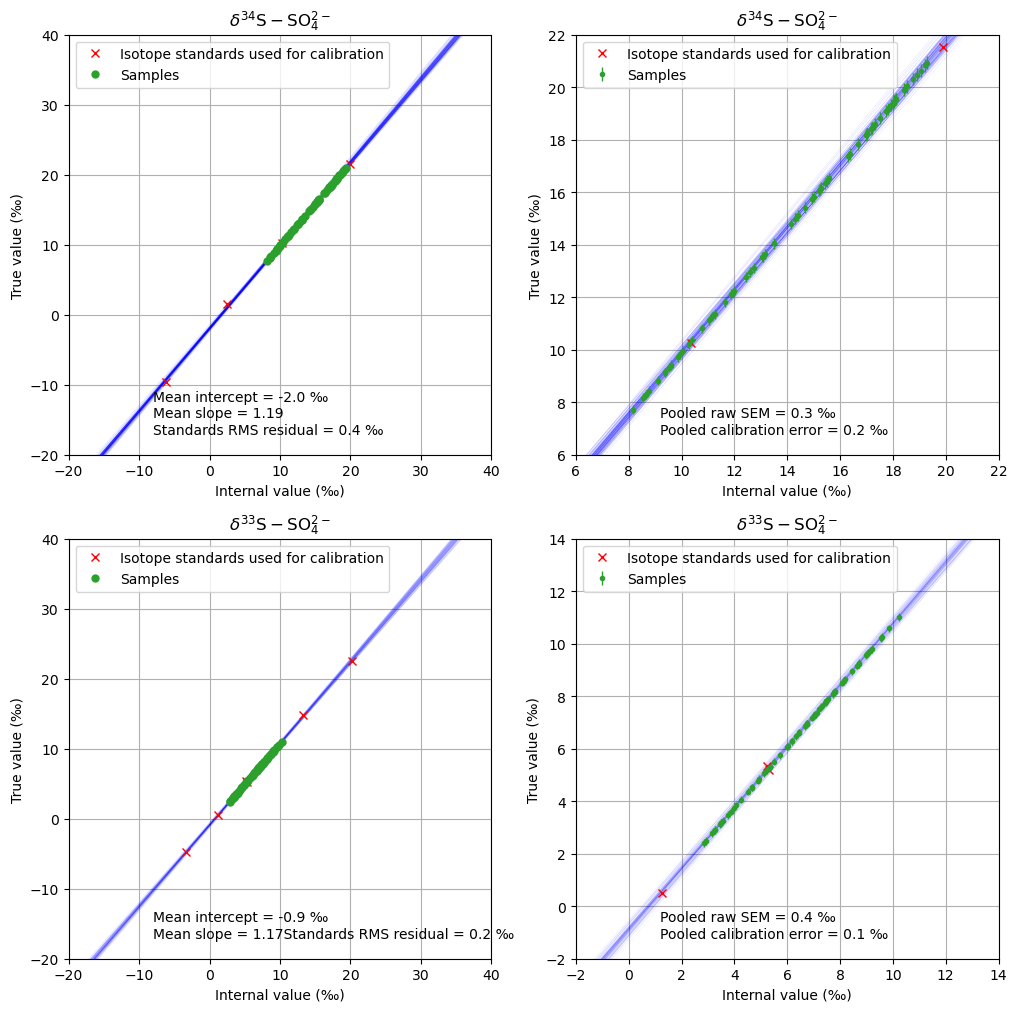

In [44]:
bp='M0'

### Sulphur calibration
slope_33=[];slope_34=[];intercept_33=[];intercept_34=[];rmse_33=[];rmse_34=[]

# plot for calib curves
fig1,ax=plt.subplots(2,2,figsize=[12,12])
for axis in ax:
    axis[0].grid()
    axis[0].set_xlabel('Internal value (‰)')
    axis[0].set_ylabel('True value (‰)')
    axis[1].grid()
    axis[1].set_xlabel('Internal value (‰)')
    axis[1].set_ylabel('True value (‰)')
ax[0][0].set_title('$\delta^{34}\mathrm{S-SO_{4}^{2-}}$')
ax[1][0].set_title('$\delta^{33}\mathrm{S-SO_{4}^{2-}}$')
ax[0][1].set_title('$\delta^{34}\mathrm{S-SO_{4}^{2-}}$')
ax[1][1].set_title('$\delta^{33}\mathrm{S-SO_{4}^{2-}}$')


for n in range(nn):
    ## 34S  calibration:
    iso='34S'
    # linear regression
    x_data=np.random.normal(stds_stats['mean_d'+iso+'_'+bp],stds_stats['err_d'+iso+'_'+bp])
    y_data=np.random.normal(refs['d'+iso],refs['err_d'+iso])
    [slope, intercept,rmse] = calib_regression(x_data,y_data)  
    # store values in lists
    slope_34+=[slope[0]]
    intercept_34+=[intercept[0]]
    rmse_34+=[rmse]

    # calibrate standard 34S values - 
    d34_cal =  (stds_stats['mean_d'+iso+'_'+bp]+1)**slope_34[-1] * np.exp(intercept_34[-1])-1
    
    # add line to plot
    x=np.linspace(-50,50,100)*1e-3
    y= ( (1+x)**slope_34[-1]*np.exp(intercept_34[-1])-1 )
    ax[0][0].plot(x*1e3,y*1e3,lw=0.2,alpha=0.2,c='b')
    ax[0][1].plot(x*1e3,y*1e3,lw=0.2,alpha=0.2,c='b')


    # 33S linear calibration based on known D33S values
    iso = '33S'   
    D_values = pd.Series(np.random.normal(refs['D33S'].dropna(), refs['err_D33S'].dropna()), index=refs['D33S'].dropna().index)
    #  calculate d33 values for VS, based on calibrated measurements and known D33S.
    d_calc_stds = pd.Series(index=stds_stats.index,dtype='float64').rename_axis('sample_name')
    for std in [std for std in stds_stats.index if std in D_values.index]:
        d_calc_stds.loc[std] = D_values.loc[std] + ((1+d34_cal.loc[std])**0.515-1)
    if False:
        print('True',iso, 'calculated for standards, based on calibrated measurements and known D33S:\n',d_calc_stds*1e3)
    # regression
    x_data=np.random.normal(stds_stats['mean_d33S_M0'],stds_stats['err_d33S_M0'])
    y_data=np.random.normal(d_calc_stds,0)
    [slope, intercept,rmse] = calib_regression(x_data,y_data)  
    # store values in lists 
    slope_33+=[slope[0]]
    intercept_33+=[intercept[0]]
    rmse_33+=[rmse]
    
    # add line to plot
    x=np.linspace(-50,50,100)*1e-3
    y= ( (1+x)**slope_33[-1]*np.exp(intercept_33[-1])-1 )
    ax[1][0].plot(x*1e3,y*1e3,lw=0.2,alpha=10/nn,c='b')
    ax[1][1].plot(x*1e3,y*1e3,lw=0.2,alpha=10/nn,c='b')
    
    
    # CALIBRATE STDS and SAMPLES
    stds_stats_pet=pd.DataFrame(index=stds_stats.index)
    stds_stats_pet['mean_d34S_M0'] = np.random.normal(stds_stats['mean_d34S_M0'],stds_stats['err_d34S_M0'])
    stds_stats_pet['mean_d33S_M0'] = np.random.normal(stds_stats['mean_d33S_M0'],stds_stats['err_d33S_M0'])
    for row in stds_cal.index:
        stds_cal.loc[row,'d34S_M0'] += [(stds_stats_pet.loc[row,'mean_d34S_M0']+1)**slope_34[-1] * np.exp(intercept_34[-1])-1]
        stds_cal.loc[row,'d33S_M0'] += [(stds_stats_pet.loc[row,'mean_d33S_M0']+1)**slope_33[-1] * np.exp(intercept_33[-1])-1]
        stds_cal.loc[row,'D33S_M0'] += [(stds_stats_pet.loc[row,'mean_d33S_M0']+1)**slope_33[-1] * np.exp(intercept_33[-1])-1 - ( ((stds_stats_pet.loc[row,'mean_d34S_M0']+1)**slope_34[-1] * np.exp(intercept_34[-1]))**0.515 -1 ) ]
    
    samples_pet=samples.copy() # no peturbing samples as we will take sem later
    for row in samples.index:
        samples_cal.loc[row,'d34S_M0'] += [(samples_pet.loc[row,'d34S_M0']+1)**slope_34[-1] * np.exp(intercept_34[-1])-1]
        samples_cal.loc[row,'d33S_M0'] += [(samples_pet.loc[row,'d33S_M0']+1)**slope_33[-1] * np.exp(intercept_33[-1])-1]
        samples_cal.loc[row,'D33S_M0'] += [(samples_pet.loc[row,'d33S_M0']+1)**slope_33[-1] * np.exp(intercept_33[-1])-1 - ( ((samples_pet.loc[row,'d34S_M0']+1)**slope_34[-1] * np.exp(intercept_34[-1]))**0.515 -1 ) ]

def averaging(df):
    df2=pd.DataFrame(columns=[col for col in df.columns]+[col+'_err' for col in df.columns], index=df.index)
    for row in df.index:
        for col in df.columns:
            df2.loc[row,col] = np.mean(df.loc[row,col])
            df2.loc[row,col+'_err'] = np.std(df.loc[row,col])
            # df2.loc[row,col] = np.median(df.loc[row,col])
            # df2.loc[row,col+'_err'] = np.percentile(df.loc[row,col],75)-np.percentile(df.loc[row,col],25)
    return df2

samples_cal_final=0; stds_cal_final=0;
samples_cal_final =averaging(samples_cal)
stds_cal_final = averaging(stds_cal)
s_new = samples_cal_final.loc[data_merged_spls.index]
s_old = samples.loc[data_merged_spls.index]
    
# add points for standards    
ax[0][0].errorbar(stds_stats['mean_d34S_M0']*1e3,refs['d34S']*1e3,
                   linestyle='none',marker='x',c='r',label='Isotope standards used for calibration')

ax[0][1].errorbar(stds_stats['mean_d34S_M0']*1e3,refs['d34S']*1e3,
                   linestyle='none',marker='x',c='r',label='Isotope standards used for calibration')
# and samples
## and samples
ax[0][0].errorbar(s_old['d34S_M0']*1e3,s_new['d34S_M0']*1e3, 
                  linestyle='',fmt='o',markersize=5,c=defcols[2],label='Samples') 
ax[0][1].errorbar(s_old['d34S_M0']*1e3,s_new['d34S_M0']*1e3, 
                  yerr = s_new['d34S_M0_err']*1e3, 
                  ls='',lw=1,fmt='o',markersize=3,c=defcols[2],label='Samples') 

# d33S points - calc
d33S_stds_calc = refs['D33S']+np.array([1+np.mean(stds_cal.loc[std,'d34S_M0']) for std in stds_cal.index])**0.515-1
ax[1][0].errorbar(stds_stats['mean_d33S_M0']*1e3,d33S_stds_calc*1e3,
                   c='r',linestyle='none',marker='x',label='Isotope standards used for calibration')    
ax[1][1].errorbar(stds_stats['mean_d33S_M0']*1e3,d33S_stds_calc*1e3,
                   c='r',linestyle='none',marker='x',label='Isotope standards used for calibration')    
## and samples
ax[1][0].errorbar(s_old['d33S_M0']*1e3,s_new['d33S_M0']*1e3, 
                  linestyle='',fmt='o',markersize=5,c=defcols[2],label='Samples') 
ax[1][1].errorbar(s_old['d33S_M0']*1e3,s_new['d33S_M0']*1e3, 
                  yerr = s_new['d33S_M0_err']*1e3, 
                  ls='',lw=1,fmt='o',markersize=3,c=defcols[2],label='Samples') 

# calculation pooled calib error
cols = [ col for col in samples_cal_final.columns if col.endswith('err')]
rows = data_merged_spls.index
errs = samples_cal_final.loc[rows,cols]
# Compute post-calibration pooled error
pooled_err_calib = pd.DataFrame(
    (np.sum(errs**2, axis=0) / len(errs.index))**0.5,
    columns=['Pooled MC calibration error'])
pooled_err_calib.index = [ind[:-4] for ind in pooled_err_calib.index]
# Merge the two df
pooled_errs = pd.concat([pooled_errs_precal,pooled_err_calib],axis=1)
# display 
print('Pooled errors:',pooled_errs * 1e3)

mean_metadata_M0 = {
                    'Intercept 34S':np.mean(intercept_34),
                    'Slope 34S':np.mean(slope_34),
                    'Intercept 33S':np.mean(intercept_33),
                    'Slope 33S':np.mean(slope_33)}

ax[0][0].legend(loc='upper left')
ax[0][1].legend(loc='upper left')
ax[0][0].set_xlim([-20,40])
ax[0][0].set_ylim([-20,40])
ax[0][1].xaxis.set_major_locator(MultipleLocator(2))
ax[0][1].yaxis.set_major_locator(MultipleLocator(2))
ax[0][1].set_xlim([6,22])
ax[0][1].set_ylim([6,22])
ax[1][0].legend(loc='upper left')
ax[1][1].legend(loc='upper left')
ax[1][0].set_xlim([-20,40])
ax[1][0].set_ylim([-20,40])
ax[1][1].xaxis.set_major_locator(MultipleLocator(2))
ax[1][1].yaxis.set_major_locator(MultipleLocator(2))
ax[1][1].set_xlim([-2,14])
ax[1][1].set_ylim([-2,14])

locx=0.2;locy=0.05

ax[0][0].text(x=locx,y=locy,
              s=
              'Mean intercept = '+f"{np.mean(intercept_34)*1e3:.1f}"+' ‰'+'\n'+
              'Mean slope = '+f"{np.mean(slope_34):.2f}\n"+
              'Standards RMS residual = '+f"{np.mean(rmse_34)*1e3:.1f}"+' ‰',
              transform=ax[0][0].transAxes)
             
ax[1][0].text(x=locx,y=locy,
              s=
              'Mean intercept = '+f"{np.mean(intercept_33)*1e3:.1f}"+' ‰'+'\n'+
              'Mean slope = '+f"{np.mean(slope_33):.2f}"+
              'Standards RMS residual = '+f"{np.mean(rmse_33)*1e3:.1f}"+' ‰',
              transform=ax[1][0].transAxes)
             
ax[0][1].text(x=locx,y=locy,
              s=
              'Pooled raw SEM = '+f"{pooled_errs.loc['d34S_M0','Pooled sample SEM']*1e3:.1f}"+' ‰\n'+
              'Pooled calibration error = '+f"{pooled_errs.loc['d34S_M0','Pooled MC calibration error']*1e3:.1f}"+' ‰',
              transform=ax[0][1].transAxes)

ax[1][1].text(x=locx,y=locy,
              s=
              'Pooled raw SEM = '+f"{pooled_errs.loc['d33S_M0','Pooled sample SEM']*1e3:.1f}"+' ‰\n'+
              'Pooled calibration error = '+f"{pooled_errs.loc['d33S_M0','Pooled MC calibration error']*1e3:.1f}"+' ‰',
              transform=ax[1][1].transAxes)


print('Mean intercept d34S:', f"{np.mean(intercept_34)*1e3:.2f}")
print('Mean slope d34S:', f"{np.mean(slope_34):.2f}")
print('Mean intercept d33S:', f"{np.mean(intercept_33)*1e3:.2f}")
print('Mean slope d33S:', f"{np.mean(slope_33):.2f}")

# fig1.savefig('CalibS.png',dpi=450)


### M0 d18O and d17O calibrations

Pooled errors:          Average single injection inter-scan SEM Pooled sample stdev  \
d17O_M0                                     2.27                2.52   
d18O_M0                                     0.89                1.35   
d33S_M0                                     0.87                0.98   
d34S_M0                                     0.37                0.79   
D17O_M0                                      NaN                 NaN   
D33S_M0                                      NaN                 NaN   

        Pooled sample SEM  Average replicates per sample M0  \
d17O_M0              1.03                           6000.00   
d18O_M0              0.55                           6000.00   
d33S_M0              0.40                           6000.00   
d34S_M0              0.32                           6000.00   
D17O_M0               NaN                               NaN   
D33S_M0               NaN                               NaN   

         Average replicates per sample

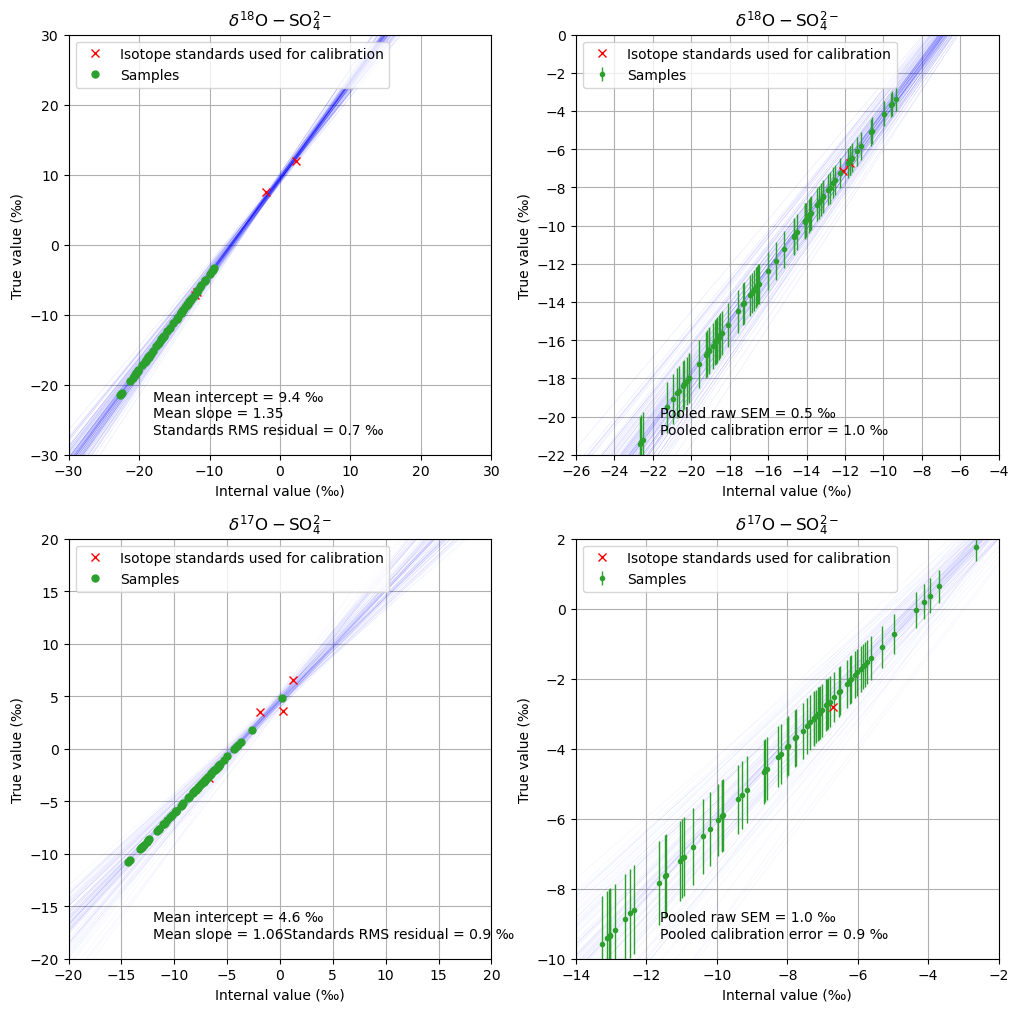

In [46]:
### Oxygen calibration

slope_17=[];slope_18=[];intercept_17=[];intercept_18=[];rmse_17=[];rmse_18=[]

# for calib curves
fig2,ax=plt.subplots(2,2,figsize=[12,12])
for axis in ax:
    axis[0].grid()
    axis[0].set_xlabel('Internal value (‰)')
    axis[0].set_ylabel('True value (‰)')
    axis[1].grid()
    axis[1].set_xlabel('Internal value (‰)')
    axis[1].set_ylabel('True value (‰)')
ax[0][0].set_title('$\delta^{18}\mathrm{O-SO_{4}^{2-}}$')
ax[1][0].set_title('$\delta^{17}\mathrm{O-SO_{4}^{2-}}$')
ax[0][1].set_title('$\delta^{18}\mathrm{O-SO_{4}^{2-}}$')
ax[1][1].set_title('$\delta^{17}\mathrm{O-SO_{4}^{2-}}$')

for n in range(nn):
    ## 18O  calibration:
    iso='18O'
    # linear regression
    x_data=np.random.normal(stds_stats['mean_d'+iso+'_'+bp],stds_stats['err_d'+iso+'_'+bp])
    y_data=np.random.normal(refs['d'+iso],refs['err_d'+iso])
    # call to regression func
    [slope, intercept,rmse] = calib_regression(x_data,y_data)  
    # store values in lists
    slope_18+=[slope[0]]
    intercept_18+=[intercept[0]]
    rmse_18+=[rmse]

    # calibrate standard 18O values - 
    d18_cal =  (stds_stats['mean_d'+iso+'_'+bp]+1)**slope * np.exp(intercept)-1
    
    # add line to plot
    x=np.linspace(-50,50,100)*1e-3
    y= ( (1+x)**slope[0]*np.exp(intercept[0])-1 )
    ax[0][0].plot(x*1e3,y*1e3,lw=0.2,alpha=0.2,c='b')
    ax[0][1].plot(x*1e3,y*1e3,lw=0.2,alpha=0.2,c='b')

    # 17O linear calibration based on known D17O values
    iso = '17O'   
    D_values = pd.Series(np.random.normal(refs['D17O'].dropna(), refs['err_D17O'].dropna()), index=refs['D17O'].dropna().index)
    #  calculate d33 values for standards, based on calibrated measurements and known D33S.
    d_calc_stds = pd.Series(index=stds_stats.index,dtype='float64').rename_axis('sample_name')
    for std in [std for std in stds_stats.index if std in D_values.index]:
        d_calc_stds.loc[std] = D_values.loc[std] + 0.52 * d18_cal.loc[std]
    if False:
        print('True',iso, 'calculated for standards, based on calibrated measurements and known D17O:\n',d_calc_stds*1e3)
    # regression
    x_data=np.random.normal(stds_stats['mean_d17O_M0'],stds_stats['err_d17O_M0'])
    y_data=np.random.normal(d_calc_stds,0)
    [slope, intercept,rmse] = calib_regression(x_data,y_data)  
    # store values in lists 
    slope_17+=[slope[0]]
    intercept_17+=[intercept[0]]
    rmse_17+=[rmse]
    
    # add line to plot
    x=np.linspace(-50,50,100)*1e-3
    y= ( (1+x)**slope[0]*np.exp(intercept[0])-1 )
    ax[1][0].plot(x*1e3,y*1e3,lw=0.2,alpha=10/nn,c='b')
    ax[1][1].plot(x*1e3,y*1e3,lw=0.2,alpha=10/nn,c='b')
    
    # CALIBRATE STDS and SAMPLES using model and the (a,b) obtained from regression; add delta values to lists to be averaged
    stds_stats_pet=pd.DataFrame(index=stds_stats.index)
    stds_stats_pet['mean_d18O_M0'] = np.random.normal(stds_stats['mean_d18O_M0'],stds_stats['err_d18O_M0'])
    stds_stats_pet['mean_d17O_M0'] = np.random.normal(stds_stats['mean_d17O_M0'],stds_stats['err_d17O_M0'])
    for row in stds_cal.index:
        stds_cal.loc[row,'d18O_M0'] += [(stds_stats_pet.loc[row,'mean_d18O_M0']+1)**slope_18[-1] * np.exp(intercept_18[-1])-1]
        stds_cal.loc[row,'d17O_M0'] += [(stds_stats_pet.loc[row,'mean_d17O_M0']+1)**slope_17[-1] * np.exp(intercept_17[-1])-1]
        stds_cal.loc[row,'D17O_M0'] += [(stds_stats_pet.loc[row,'mean_d17O_M0']+1)**slope_17[-1] * np.exp(intercept_17[-1])-1 - 0.52*((stds_stats_pet.loc[row,'mean_d18O_M0']+1)**slope_18[-1]* np.exp(intercept_18[-1])-1) ]
    
    samples_pet=samples.copy() # no peturbing samples as we will take sem later
    for row in samples.index:
        samples_cal.loc[row,'d18O_M0'] += [(samples_pet.loc[row,'d18O_M0']+1)**slope_18[-1] * np.exp(intercept_18[-1])-1]
        samples_cal.loc[row,'d17O_M0'] += [(samples_pet.loc[row,'d17O_M0']+1)**slope_17[-1] * np.exp(intercept_17[-1])-1]
        samples_cal.loc[row,'D17O_M0'] += [(samples_pet.loc[row,'d17O_M0']+1)**slope_17[-1] * np.exp(intercept_17[-1])-1 - 0.52*((samples_pet.loc[row,'d18O_M0']+1)**slope_18[-1]* np.exp(intercept_18[-1])-1) ]

def averaging(df):
    df2=pd.DataFrame(columns=[col for col in df.columns]+[col+'_err' for col in df.columns], index=df.index)
    for row in df.index:
        for col in df.columns:
            df2.loc[row,col] = np.mean(df.loc[row,col])
            df2.loc[row,col+'_err'] = np.std(df.loc[row,col])
            # df2.loc[row,col] = np.median(df.loc[row,col])
            # df2.loc[row,col+'_err'] = np.percentile(df.loc[row,col],75)-np.percentile(df.loc[row,col],25)
    return df2

samples_cal_final=0; stds_cal_final=0;
samples_cal_final =averaging(samples_cal)
stds_cal_final = averaging(stds_cal)
s_new = samples_cal_final.loc[data_merged_spls.index]
s_old = samples.loc[data_merged_spls.index]
    
# add points for standards    
ax[0][0].errorbar(stds_stats['mean_d18O_M0']*1e3,refs['d18O']*1e3,
                   linestyle='none',marker='x',c='r',label='Isotope standards used for calibration')

ax[0][1].errorbar(stds_stats['mean_d18O_M0']*1e3,refs['d18O']*1e3,
                   linestyle='none',marker='x',c='r',label='Isotope standards used for calibration')
# and samples
## and samples
ax[0][0].errorbar(s_old['d18O_M0']*1e3,s_new['d18O_M0']*1e3, 
                  linestyle='',fmt='o',markersize=5,c=defcols[2],label='Samples') 
ax[0][1].errorbar(s_old['d18O_M0']*1e3,s_new['d18O_M0']*1e3, 
                  yerr = s_new['d18O_M0_err']*1e3, 
                  ls='',lw=1,fmt='o',markersize=3,c=defcols[2],label='Samples') 

# d17O points - calc
d17O_stds_calc = refs['D17O']+0.52*np.array([np.mean(stds_cal.loc[std,'d18O_M0']) for std in stds_cal.index])
ax[1][0].errorbar(stds_stats['mean_d17O_M0']*1e3,d17O_stds_calc*1e3,
                   c='r',linestyle='none',marker='x',label='Isotope standards used for calibration')    
ax[1][1].errorbar(stds_stats['mean_d17O_M0']*1e3,d17O_stds_calc*1e3,
                   c='r',linestyle='none',marker='x',label='Isotope standards used for calibration')    
## and samples
ax[1][0].errorbar(s_old['d17O_M0']*1e3,s_new['d17O_M0']*1e3, 
                  linestyle='',fmt='o',markersize=5,c=defcols[2],label='Samples') 
ax[1][1].errorbar(s_old['d17O_M0']*1e3,s_new['d17O_M0']*1e3, 
                  yerr = s_new['d17O_M0_err']*1e3, 
                  ls='',lw=1,fmt='o',markersize=3,c=defcols[2],label='Samples') 


# calculation pooled calib error
cols = [ col for col in samples_cal_final.columns if col.endswith('err')]
rows = data_merged_spls.index
errs = samples_cal_final.loc[rows,cols]
# Compute post-calibration pooled error
pooled_err_calib = pd.DataFrame(
    (np.sum(errs**2, axis=0) / len(errs.index))**0.5,
    columns=['Pooled MC calibration error'])
pooled_err_calib.index = [ind[:-4] for ind in pooled_err_calib.index]
# Merge the two df
pooled_errs = pd.concat([pooled_errs_precal,pooled_err_calib],axis=1)
# display 
print('Pooled errors:',pooled_errs * 1e3)


mean_metadata_M0 = {'Intercept 34S':np.mean(intercept_34),
                    'Slope 34S':np.mean(slope_34),
                    'Intercept 33S':np.mean(intercept_33),
                    'Slope 33S':np.mean(slope_33),
                    'Intercept 18O':np.mean(intercept_18),
                    'Slope 18O':np.mean(slope_18),
                    'Intercept 17O':np.mean(intercept_17),
                    'Slope 17O':np.mean(slope_17)}

ax[0][0].legend(loc='upper left')
ax[0][1].legend(loc='upper left')
ax[0][0].set_xlim([-30,30])
ax[0][0].set_ylim([-30,30])
ax[0][1].xaxis.set_major_locator(MultipleLocator(2))
ax[0][1].yaxis.set_major_locator(MultipleLocator(2))
ax[0][1].set_ylim([-22,-0])
ax[0][1].set_xlim([-26,-4])
ax[1][0].legend(loc='upper left')
ax[1][1].legend(loc='upper left')
ax[1][0].set_xlim([-20,20])
ax[1][0].set_ylim([-20,20])
ax[1][1].xaxis.set_major_locator(MultipleLocator(2))
ax[1][1].yaxis.set_major_locator(MultipleLocator(2))
ax[1][1].set_xlim([-14,-2])
ax[1][1].set_ylim([-10,2])

locx=0.2;locy=0.05

ax[0][0].text(x=locx,y=locy,
              s=
              'Mean intercept = '+f"{np.mean(intercept_18)*1e3:.1f}"+' ‰'+'\n'+
              'Mean slope = '+f"{np.mean(slope_18):.2f}\n"+
              'Standards RMS residual = 'f"{np.mean(rmse_18)*1e3:.1f}"+' ‰',
              transform=ax[0][0].transAxes)
             
ax[1][0].text(x=locx,y=locy,
              s=
              'Mean intercept = '+f"{np.mean(intercept_17)*1e3:.1f}"+' ‰'+'\n'+
              'Mean slope = '+f"{np.mean(slope_17):.2f}"+
              'Standards RMS residual = 'f"{np.mean(rmse_17)*1e3:.1f}"+' ‰',
              transform=ax[1][0].transAxes)
             
ax[0][1].text(x=locx,y=locy,
              s=
              'Pooled raw SEM = '+f"{pooled_errs.loc['d18O_M0','Pooled sample SEM']*1e3:.1f}"+' ‰\n'+
              'Pooled calibration error = '+f"{pooled_errs.loc['d18O_M0','Pooled MC calibration error']*1e3:.1f}"+' ‰',
              transform=ax[0][1].transAxes)

ax[1][1].text(x=locx,y=locy,
              s=
              'Pooled raw SEM = '+f"{pooled_errs.loc['d17O_M0','Pooled sample SEM']*1e3:.1f}"+' ‰\n'+
              'Pooled calibration error = '+f"{pooled_errs.loc['d17O_M0','Pooled MC calibration error']*1e3:.1f}"+' ‰',
              transform=ax[1][1].transAxes)


             

print('Mean intercept d18O:', f"{np.mean(intercept_18)*1e3:.2f}")
print('Mean slope d18O:', f"{np.mean(slope_18):.2f}")
print('Mean intercept d17O:', f"{np.mean(intercept_17)*1e3:.2f}")
print('Mean slope d17O:', f"{np.mean(slope_17):.2f}")

# fig2.savefig('CalibO-So4.png',dpi=450)

## Averaging the $nn$ $\delta$-values for each isotopologue ratio
Calculates mean and standard deviation (alternatively median and IQR) of $nn$ values for each isotopologue ratio for each sample or standard

In [47]:
def averaging(df):
    df2=pd.DataFrame(columns=[col for col in df.columns]+[col+'_err' for col in df.columns], index=df.index)
    for row in df.index:
        for col in df.columns:
            df2.loc[row,col] = np.mean(df.loc[row,col])
            df2.loc[row,col+'_err'] = np.std(df.loc[row,col])
            # df2.loc[row,col] = np.median(df.loc[row,col])
            # df2.loc[row,col+'_err'] = np.percentile(df.loc[row,col],75)-np.percentile(df.loc[row,col],25)
    return df2

samples_cal_final=0; stds_cal_final=0;
samples_cal_final =averaging(samples_cal)
stds_cal_final = averaging(stds_cal)

samples['sample_name']=data_merged['sample_name']
samples['blockname']=data_merged['blockname']
samples_cal_final['sample_name']=data_merged['sample_name']
samples_cal_final['blockname']=data_merged['blockname']
pd.concat([samples_cal_final[['sample_name','blockname']],samples_cal_final[[col for col in samples_cal_final.columns if col not in ('blockname','sample_name')]] *1e3],axis=1)
                                                               
                                                               

,sample_name,blockname,d17O_M0,d18O_M0,d33S_M0,d34S_M0,D17O_M0,D33S_M0,d17O_M0_err,d18O_M0_err,d33S_M0_err,d34S_M0_err,D17O_M0_err,D33S_M0_err
0,Alpha-1,250321_078,-5.40,-7.86,3.04,10.03,-1.31,-2.11,0.97,0.82,0.14,0.18,0.84,0.12
1,Alpha-1,250321_076,-2.58,-8.99,5.47,8.62,2.10,1.04,0.72,0.87,0.13,0.17,0.61,0.11
2,Alpha-1,250321_080,-2.89,-8.12,5.38,10.90,1.33,-0.22,0.75,0.83,0.13,0.18,0.63,0.11
3,Alpha-1,250321_074,-2.13,-9.25,3.73,9.90,2.68,-1.36,0.69,0.88,0.14,0.18,0.58,0.12
4,Alpha-1,250321_072,-5.31,-4.76,6.05,10.74,-2.84,0.53,0.97,0.69,0.13,0.18,0.85,0.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,UW8-3,250321_176,5.43,11.09,-5.29,-9.74,-0.34,-0.26,0.39,0.37,0.20,0.24,0.37,0.18
176,UW8-3,250321_164,5.46,13.11,-6.86,-9.26,-1.36,-2.08,0.39,0.42,0.22,0.24,0.39,0.19
177,UW8-3,250321_220,9.04,12.01,-5.48,-9.45,2.80,-0.60,0.62,0.39,0.20,0.24,0.58,0.18
178,UW8-3,250321_194,4.69,12.10,-4.75,-9.36,-1.60,0.08,0.36,0.40,0.20,0.24,0.36,0.17


### Calculate and display pooled uncertainties pre-and post-calibration

Calculation: 

#### $\sqrt{\frac{\sum \sigma_\delta^2}{n}}$

For standard error $\sigma_\delta$ on $\delta$-values, for $n$ different samples

In [48]:
# calculate D17O and D33S errors
std17=[]
sem17=[]
D17O_stats=pd.DataFrame(columns=['mean_'+d for d in dcols]+['err_'+d for d in dcols])
samples_cal_final_samples_only = samples_cal_final[~ samples_cal_final['sample_name'].str.startswith(tuple(stds_dict.keys()))]
for spl, group in samples_cal_final_samples_only.groupby('sample_name'):
    std17 += [group['D17O_M0'].std()]
    sem17 += [group['D17O_M0'].std() /np.sqrt( len(group)) ]
std17 = pd.Series(std17).dropna()
sem17 = pd.Series(sem17).dropna()
pooled_std17 = np.sqrt(np.sum(std17**2)/len(std17))
pooled_sem17 = np.sqrt(np.sum(sem17**2)/len(sem17))
pooled_errs.loc['D17O_M0','Pooled sample stdev'] = pooled_std17
pooled_errs.loc['D17O_M0','Pooled sample SEM'] = pooled_sem17


std33=[]
sem33=[]
D33S_stats=pd.DataFrame(columns=['mean_'+d for d in dcols]+['err_'+d for d in dcols])
samples_cal_final_samples_only = samples_cal_final[~ samples_cal_final['sample_name'].str.startswith(tuple(stds_dict.keys()))]
for spl, group in samples_cal_final_samples_only.groupby('sample_name'):
    std33 += [group['D33S_M0'].std()]
    sem33 += [group['D33S_M0'].std() /np.sqrt( len(group)) ]
std33 = pd.Series(std17).dropna()
sem33 = pd.Series(sem17).dropna()
pooled_std33 = np.sqrt(np.sum(std17**2)/len(std33))
pooled_sem33 = np.sqrt(np.sum(sem17**2)/len(sem33))
pooled_errs.loc['D33S_M0','Pooled sample stdev'] = pooled_std33
pooled_errs.loc['D33S_M0','Pooled sample SEM'] = pooled_sem33


# combine the two error types
pooled_errs['Total uncertainty = sqrt( SEM^2 + MC^2 )']=(pooled_errs['Pooled sample SEM']**2+pooled_errs['Pooled MC calibration error']**2)**0.5


print('Pooled errors:')
pooled_errs[['Average single injection inter-scan SEM','Pooled sample stdev','Pooled sample SEM','Pooled MC calibration error','Total uncertainty = sqrt( SEM^2 + MC^2 )']]*1e3
            

Pooled errors:


,Average single injection inter-scan SEM,Pooled sample stdev,Pooled sample SEM,Pooled MC calibration error,Total uncertainty = sqrt( SEM^2 + MC^2 )
d17O_M0,2.27,2.52,1.03,0.93,1.38
d18O_M0,0.89,1.35,0.55,1.04,1.18
d33S_M0,0.87,0.98,0.40,0.14,0.42
d34S_M0,0.37,0.79,0.32,0.21,0.38
D17O_M0,NaN,2.66,1.09,0.80,1.35
D33S_M0,NaN,2.66,1.09,0.12,1.09


## Save to excel file

In [49]:
output_file = os.getcwd().split('/')[-1]+'_calibrated_'+data_type+'_'+current_date_string+'.xlsx'

if data_type=='M0+noM0':
    to_save = {'Small deltas uncalibrated':samples,
               'Small deltas calibrated':samples_cal_final,
               'Calibration metadata M0': pd.DataFrame(mean_metadata_M0.items()),
              'Calibration metadata no-M0': pd.DataFrame(mean_metadata_noM0.items()),
              'Pooled raw errors': pooled_errs}
else:
    to_save = {'Small deltas uncalibrated':samples,
               'Small deltas calibrated':samples_cal_final,
               'Calibration metadata M0': pd.DataFrame(mean_metadata_M0.items()),
              'Pooled errors': pooled_errs              }

for sheet_name, df in to_save.items():
    # Check if the file exists
    if not os.path.exists(os.path.join(output_file)):
        # If the file doesn't exist, create a new ExcelWriter object without mode='a'
        with pd.ExcelWriter(os.path.join(output_file), engine='openpyxl') as writer:
            # Write the DataFrame to a new sheet with the specified sheet name
            df.to_excel(writer, sheet_name=sheet_name, index=True)
            print('Excel file created:',os.path.join(output_file),'\nNew sheet added to',output_file,':',sheet_name)
    else:
        # If the file exists, create an ExcelWriter object with mode='a' to append to the existing file
        with pd.ExcelWriter(os.path.join(output_file), engine='openpyxl', mode='a',if_sheet_exists='replace') as writer:
            # Write the DataFrame to a new sheet with the specified sheet name
            df.to_excel(writer, sheet_name=sheet_name, index=True)
            print('New sheet added to',output_file,':',sheet_name)

Excel file created: sulphate_calibrated_M0-only_2026-04-10.xlsx 
New sheet added to sulphate_calibrated_M0-only_2026-04-10.xlsx : Small deltas uncalibrated
New sheet added to sulphate_calibrated_M0-only_2026-04-10.xlsx : Small deltas calibrated
New sheet added to sulphate_calibrated_M0-only_2026-04-10.xlsx : Calibration metadata M0
New sheet added to sulphate_calibrated_M0-only_2026-04-10.xlsx : Pooled errors
